# G3 — Multi-Agent Path Finding en 2D

**EPITA 2026 — Programmation par Contraintes**  
*Matteo Atkinson & Paul Witkowski*

---

## Le problème MAPF

Le **Multi-Agent Path Finding (MAPF)** consiste à calculer des trajectoires **optimales et sans collision** pour un ensemble d'agents (ici des drones) partageant une grille 2D. C'est un problème NP-hard fondamental en robotique et logistique.

### Types de conflits

| Conflit | Description | Illustration |
|---------|-------------|-------------|
| **Sommet** | Deux agents au même nœud au même instant `t` | `A et B en (r,c) à t=3` |
| **Arête** | Deux agents échangent leurs positions entre `t` et `t+1` | `A:(p→q), B:(q→p) simultanément` |

### Métriques d'évaluation

| Métrique | Définition | Formule |
|----------|------------|--------|
| **Makespan** | Temps du dernier arrivant | `max(arrival_i)` |
| **Flowtime** | Somme des temps d'arrivée | `sum(arrival_i)` |
| **Solve time** | Temps de calcul | en millisecondes |

### Algorithmes comparés dans ce notebook

| Algorithme | Approche | Garantie d'optimalité |
|------------|----------|----------------------|
| **CP-SAT** | Programmation par contraintes (OR-Tools) | Optimal (makespan) |
| **CBS** | Conflict-Based Search | Optimal (flowtime) |
| **ECBS** | Enhanced CBS avec liste FOCAL | w-sous-optimal (w=1.3) |
| **OD-A\*** | A\* avec Operator Decomposition | Optimal (flowtime)¹ |

¹ *L'implémentation présente une incohérence heuristique (h=Σ BFS vs g=timesteps) qui peut produire des résultats sous-optimaux — voir section 6.*

In [38]:
import sys, time
sys.path.insert(0, '..')
from solver.grid import Grid
from solver.mapf import Drone, MAPFSolver
from solver.cbs import CBSSolver, ECBSSolver, find_first_conflict
from solver.od_astar import ODAstarSolver
from solver.astar import astar
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import numpy as np
from IPython.display import HTML

plt.rcParams['figure.facecolor'] = '#0f172a'
COLORS = ['#3b82f6','#ef4444','#22c55e','#f59e0b','#a855f7','#06b6d4','#ec4899','#84cc16']
BG, GL, OBS = '#0f172a', '#1e3a5f', '#334155'
print('Imports OK')

Imports OK


In [39]:
def setup_ax(ax, grid, title=''):
    ax.set_xlim(-0.5, grid.cols - 0.5)
    ax.set_ylim(-0.5, grid.rows - 0.5)
    ax.set_facecolor(BG)
    ax.set_aspect('equal')
    ax.invert_yaxis()
    ax.set_title(title, color='white', fontsize=10)
    for r in range(grid.rows + 1):
        ax.axhline(r - 0.5, color=GL, lw=0.5)
    for c in range(grid.cols + 1):
        ax.axvline(c - 0.5, color=GL, lw=0.5)
    for obs in grid.obstacles:
        ax.add_patch(plt.Rectangle((obs[1]-.5, obs[0]-.5), 1, 1, color=OBS))
    ax.tick_params(colors='#64748b', labelsize=7)

def draw_starts_goals(ax, drones):
    for i, d in enumerate(drones):
        col = COLORS[i % len(COLORS)]
        ax.plot(d.start[1], d.start[0], 's', ms=10, color=col, alpha=0.5)
        ax.text(d.start[1], d.start[0], str(i), ha='center', va='center',
                color='white', fontsize=7, fontweight='bold', zorder=4)
        ax.plot(d.goal[1], d.goal[0], '*', ms=14, color=col)

def animate_solution(grid, sol, drones, title=''):
    fig, ax = plt.subplots(figsize=(7, 7))
    fig.patch.set_facecolor(BG)
    setup_ax(ax, grid, title)
    draw_starts_goals(ax, drones)
    dots = [ax.plot([], [], 'o', ms=14, color=COLORS[i % len(COLORS)])[0]
            for i in range(len(drones))]
    txts = [ax.text(0, 0, str(i), ha='center', va='center',
                    color='white', fontsize=8, fontweight='bold', visible=False)
            for i in range(len(drones))]

    def update(frame):
        for i, d in enumerate(drones):
            path = sol.paths.get(d.id, [])
            if not path:
                dots[i].set_data([], [])
                txts[i].set_visible(False)
                continue
            pos = path[min(frame, len(path) - 1)]
            dots[i].set_data([pos[1]], [pos[0]])
            txts[i].set_position((pos[1], pos[0]))
            txts[i].set_visible(True)
        ax.set_title(
            f'{title}  t={frame}/{sol.makespan}  '
            f'[{sol.status} | makespan={sol.makespan} | flowtime={sol.flowtime} | {sol.solve_time_ms:.0f}ms]',
            color='white', fontsize=9)
        return dots + txts

    return animation.FuncAnimation(fig, update, frames=sol.makespan + 2,
                                   interval=400, blit=True)

print('Helpers definis.')

Helpers definis.


---
## 1. Grille 2D et A* — recherche de chemin pour un agent unique

La **grille** est l'abstraction de l'espace. Un agent peut se déplacer vers les 4 cellules adjacentes ou attendre sur place. Les **obstacles** sont des cellules inaccessibles.

L'algorithme **A*** trouve le chemin le plus court pour un seul agent en utilisant l'heuristique de Manhattan : `h(p) = |row_p - row_goal| + |col_p - col_goal|`.

A* | longueur du chemin : 14 pas
Chemin : [(0, 0), (0, 1), (0, 2), (0, 3), (0, 4), (0, 5), (0, 6), (0, 7), (1, 7), (2, 7), (3, 7), (4, 7), (5, 7), (6, 7), (7, 7)]


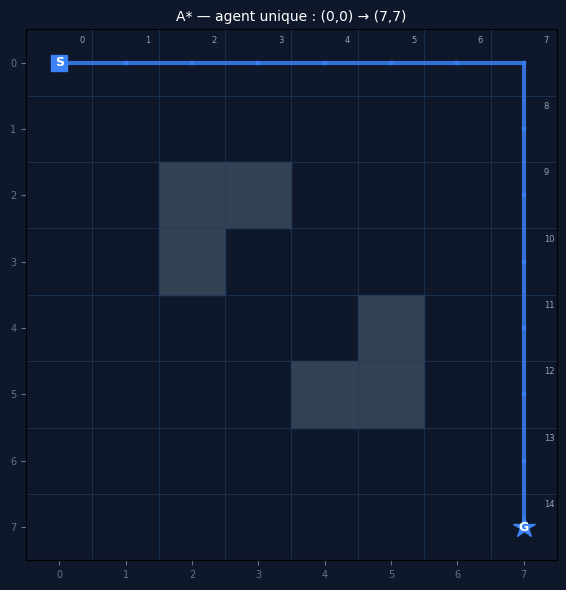

In [40]:
# Grille 8x8 avec obstacles — A* pour un agent
grid1 = Grid(rows=8, cols=8)
for obs in [(2,2),(2,3),(3,2),(5,4),(5,5),(4,5)]:
    grid1.obstacles.add(obs)

drone0 = Drone(0, (0,0), (7,7))
path0 = astar(grid1, drone0.start, drone0.goal)
print(f'A* | longueur du chemin : {len(path0)-1} pas')
print(f'Chemin : {path0}')

fig, ax = plt.subplots(figsize=(6, 6))
fig.patch.set_facecolor(BG)
setup_ax(ax, grid1, 'A* — agent unique : (0,0) → (7,7)')
for i in range(len(path0) - 1):
    p0, p1 = path0[i], path0[i+1]
    ax.plot([p0[1], p1[1]], [p0[0], p1[0]], color=COLORS[0], lw=3, alpha=0.85)
ax.plot(path0[0][1], path0[0][0], 's', ms=12, color=COLORS[0])
ax.plot(path0[-1][1], path0[-1][0], '*', ms=16, color=COLORS[0])
ax.text(path0[0][1], path0[0][0], 'S', ha='center', va='center', color='white', fontsize=9, fontweight='bold')
ax.text(path0[-1][1], path0[-1][0], 'G', ha='center', va='center', color='white', fontsize=9, fontweight='bold')
for i, pos in enumerate(path0):
    ax.text(pos[1]+0.3, pos[0]-0.3, str(i), color='#94a3b8', fontsize=6)
plt.tight_layout()
plt.show()

---
## 2. Conflits MAPF — pourquoi A* seul ne suffit pas

Lorsque plusieurs agents utilisent A* indépendamment, sans connaissance des autres agents, des **conflits** apparaissent.

**Scénario** : 2 drones sur une grille 5×5. Drone 0 va de gauche à droite, Drone 1 de droite à gauche sur la même ligne — ils se croisent nécessairement.

Chemins A* naifs (chaque agent ignore les autres):
  Drone 0: [(2, 0), (2, 1), (2, 2), (2, 3), (2, 4)]
  Drone 1: [(2, 4), (2, 3), (2, 2), (2, 1), (2, 0)]

Premier conflit detecte : ('vertex', 0, 1, (2, 2), 2)
  -> Conflit de SOMMET : drones 0 et 1 tous deux en (2, 2) a t=2


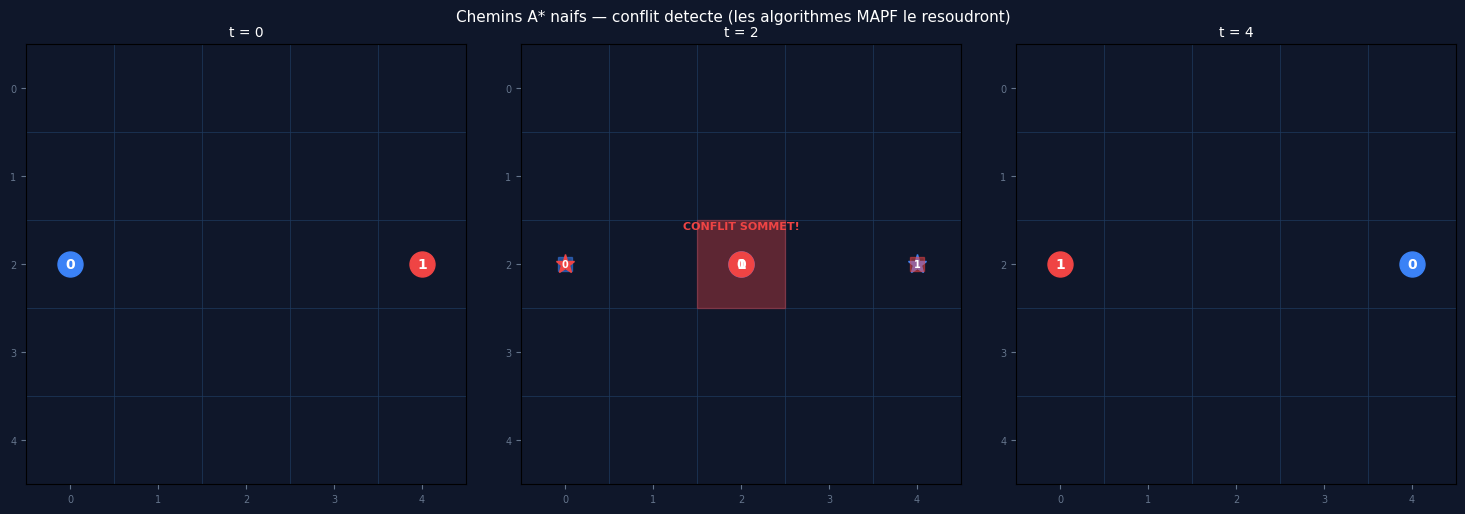

In [41]:
# Conflits : 2 drones se croisant de face (edge conflict)
grid_c = Grid(rows=5, cols=5)
drones_c = [Drone(0, (2,0), (2,4)), Drone(1, (2,4), (2,0))]

naive = {d.id: astar(grid_c, d.start, d.goal) for d in drones_c}
print('Chemins A* naifs (chaque agent ignore les autres):')
for d in drones_c:
    print(f'  Drone {d.id}: {naive[d.id]}')

conflict = find_first_conflict(naive)
print(f'\nPremier conflit detecte : {conflict}')
if conflict[0] == 'vertex':
    _, a, b, pos, t = conflict
    print(f'  -> Conflit de SOMMET : drones {a} et {b} tous deux en {pos} a t={t}')
else:
    _, a, b, pa, pb, t = conflict
    print(f'  -> Conflit d\'ARETE : drone {a} ({pa}->{pb}) et drone {b} ({pb}->{pa}) a t={t}')

# Visualisation a 3 instants
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.patch.set_facecolor(BG)
for idx, (t_show, ax) in enumerate(zip([0, 2, 4], axes)):
    setup_ax(ax, grid_c, f't = {t_show}')
    draw_starts_goals(ax, drones_c)
    for i, d in enumerate(drones_c):
        path = naive[d.id]
        pos = path[min(t_show, len(path)-1)]
        col = COLORS[i % len(COLORS)]
        ax.plot(pos[1], pos[0], 'o', ms=18, color=col, zorder=5)
        ax.text(pos[1], pos[0], str(i), ha='center', va='center',
                color='white', fontsize=10, fontweight='bold', zorder=6)
    # Surligner le conflit
    if conflict and conflict[0] == 'edge' and t_show == conflict[5]:
        for cpos in [conflict[3], conflict[4]]:
            ax.add_patch(plt.Rectangle((cpos[1]-.5, cpos[0]-.5), 1, 1,
                                       color='#ef4444', alpha=0.35, zorder=3))
        ax.text(2, -0.4, 'CONFLIT ARETE!', ha='center', color='#ef4444',
                fontsize=8, fontweight='bold')
    elif conflict and conflict[0] == 'vertex' and t_show == conflict[4]:
        cpos = conflict[3]
        ax.add_patch(plt.Rectangle((cpos[1]-.5, cpos[0]-.5), 1, 1,
                                   color='#ef4444', alpha=0.35, zorder=3))
        ax.text(cpos[1], cpos[0]-0.4, 'CONFLIT SOMMET!', ha='center', color='#ef4444',
                fontsize=8, fontweight='bold')

plt.suptitle('Chemins A* naifs — conflit detecte (les algorithmes MAPF le resoudront)',
             color='white', fontsize=11)
plt.tight_layout()
plt.show()

---
## 3. CP-SAT — Modélisation par programmation par contraintes

CP-SAT modélise MAPF comme un **problème de satisfaction de contraintes** résolu par Google OR-Tools.

### Variables
- `here[a,p,t] ∈ {0,1}` : vrai si le drone `a` occupe la position `p` au temps `t`
- `move[a,p,q,t] ∈ {0,1}` : vrai si le drone `a` se déplace de `p` vers `q` entre `t` et `t+1`

### Contraintes

| # | Contrainte | Rôle |
|---|-----------|------|
| 1 | `AddExactlyOne(here[a,:,t])` | Un agent occupe exactement une case par timestep |
| 2 | `here[a,start,0] = 1` | Position initiale fixée |
| 3 | `Σ move[a,p,→,t] = here[a,p,t]` | Conservation du flux sortant |
| 3 | `Σ move[a,→,p,t] = here[a,p,t+1]` | Conservation du flux entrant |
| 4 | `AddNoOverlap(OptionalIntervalVar/position)` | **Anti-conflit sommet** : un seul agent par case |
| 5 | `AddNoOverlap(OptionalIntervalVar/arc)` | **Anti-conflit arête** : pas d'échange simultané |
| 6 | `here[a,goal,t+1] ≥ here[a,goal,t]` | Persistance au but |

### Objectif
`Minimize(makespan)` où `makespan = max(T+1 - Σ here[a,goal,:])` pour tous les agents.

### Réduction de domaine
BFS depuis chaque départ et vers chaque arrivée : `here[a,p,t]` n'est créé que si `dist_start[a][p] ≤ t` et `dist_goal[a][p] ≤ T-t`. Cela réduit drastiquement le nombre de variables.

CP-SAT | status=optimal | makespan=14 | flowtime=53 | 4343ms
Chemins trouves:
  Drone 0: [(0, 0), (0, 1), (0, 2), (0, 3), (0, 4), (0, 5), (0, 6), (0, 7), (1, 7), (2, 7), (3, 7), (4, 7), (5, 7), (6, 7), (7, 7)]
  Drone 1: [(7, 0), (6, 0), (5, 0), (4, 0), (3, 0), (2, 0), (1, 0), (0, 0), (0, 1), (0, 2), (0, 3), (0, 4), (0, 5), (0, 6), (0, 7)]
  Drone 2: [(0, 7), (0, 6), (0, 5), (0, 4), (1, 4), (1, 3), (1, 2), (1, 1), (1, 0), (2, 0), (3, 0), (4, 0), (5, 0), (6, 0), (7, 0)]
  Drone 3: [(3, 0), (3, 1), (3, 2), (2, 2), (2, 3), (2, 4), (1, 4), (1, 5), (1, 6), (1, 7), (2, 7), (3, 7), (3, 7), (3, 7), (3, 7)]


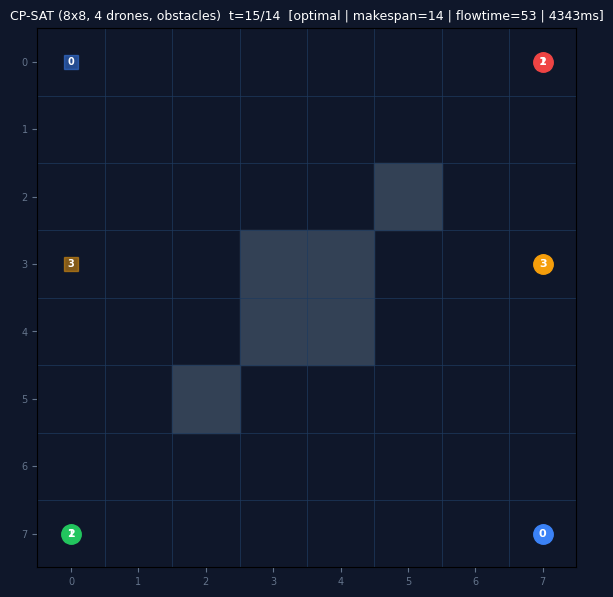

In [42]:
# CP-SAT : 4 drones se croisant sur grille 8x8 avec obstacles
grid_cp = Grid(rows=8, cols=8)
# Mur central en croix : force les drones a contourner et cree des conflits
for obs in [(3,3),(3,4),(4,3),(4,4),(2,5),(5,2)]:
    grid_cp.obstacles.add(obs)

drones_cp = [
    Drone(0, (0,0), (7,7)),
    Drone(1, (7,0), (0,7)),
    Drone(2, (0,7), (7,0)),
    Drone(3, (3,0), (3,7)),
]

sol_cp = MAPFSolver(grid_cp, drones_cp, time_limit_s=30).solve()
print(f'CP-SAT | status={sol_cp.status} | makespan={sol_cp.makespan} | flowtime={sol_cp.flowtime} | {sol_cp.solve_time_ms:.0f}ms')
print('Chemins trouves:')
for d in drones_cp:
    print(f'  Drone {d.id}: {sol_cp.paths[d.id]}')

anim_cp = animate_solution(grid_cp, sol_cp, drones_cp, 'CP-SAT (8x8, 4 drones, obstacles)')
HTML(anim_cp.to_jshtml())

---
## 4. CBS — Conflict-Based Search

CBS utilise un arbre de contraintes (**Conflict Tree**) à deux niveaux.

### Algorithme
1. **Niveau bas** : A* espace-temps pour chaque agent individuellement, respectant ses contraintes
2. **Niveau haut** : Explorer l'arbre de contraintes
   - Nœud racine : chemins A* sans contraintes
   - Détecter le premier conflit dans les chemins combinés
   - Si **aucun conflit** → solution trouvée ✓
   - Si **conflit** → créer 2 enfants, chacun ajoutant une contrainte pour l'un des agents
   - Choisir le nœud de **coût minimal** (somme des longueurs de chemins)

### Propriétés
- **Complet** : trouve toujours une solution si elle existe
- **Optimal** : minimise le **flowtime** (somme des longueurs)
- **Complexité** : exponentielle dans le nombre de conflits (pire cas)

CBS   | status=optimal | makespan=14 | flowtime=53 | 8ms

Comparaison CP-SAT vs CBS (meme instance):
  CP-SAT : makespan=14, flowtime=53, 4343ms
  CBS    : makespan=14, flowtime=53, 8ms
Note: CP-SAT optimise le makespan, CBS optimise le flowtime -> resultats potentiellement differents


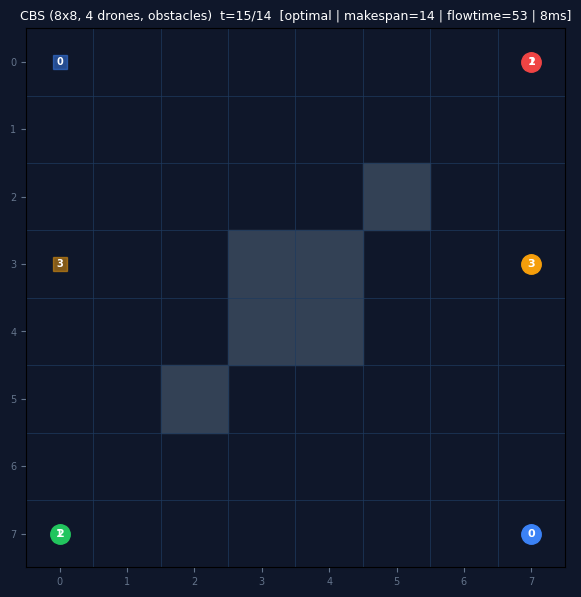

In [43]:
# CBS : meme instance que CP-SAT pour comparaison directe
sol_cbs = CBSSolver(grid_cp, drones_cp, time_limit_s=30).solve()
print(f'CBS   | status={sol_cbs.status} | makespan={sol_cbs.makespan} | flowtime={sol_cbs.flowtime} | {sol_cbs.solve_time_ms:.0f}ms')

print('\nComparaison CP-SAT vs CBS (meme instance):')
print(f'  CP-SAT : makespan={sol_cp.makespan}, flowtime={sol_cp.flowtime}, {sol_cp.solve_time_ms:.0f}ms')
print(f'  CBS    : makespan={sol_cbs.makespan}, flowtime={sol_cbs.flowtime}, {sol_cbs.solve_time_ms:.0f}ms')
print('Note: CP-SAT optimise le makespan, CBS optimise le flowtime -> resultats potentiellement differents')

anim_cbs = animate_solution(grid_cp, sol_cbs, drones_cp, 'CBS (8x8, 4 drones, obstacles)')
HTML(anim_cbs.to_jshtml())

---
## 5. ECBS — Enhanced CBS

ECBS améliore CBS en introduisant une **liste FOCAL** : parmi tous les nœuds dont le coût est inférieur à `w × f_min`, on choisit celui avec le **moins de conflits** plutôt que le moindre coût.

### Algorithme ECBS
1. Calculer `f_min` = coût minimal dans OPEN (O(1) via le tas-min)
2. Construire `FOCAL = {n ∈ OPEN | cost(n) ≤ w × f_min}`
3. Choisir dans FOCAL le nœud minimisant `nb_conflicts(n)`
4. **Suppression paresseuse** (`lazy deletion`) : les nœuds supprimés sont marqués dans `deleted_ids` et retirés progressivement du tas

### Garantie w-sous-optimale
La solution trouvée a un coût ≤ `w × coût_optimal`. Avec `w=1.3`, on accepte jusqu'à 30% de sous-optimalité en échange d'une résolution plus rapide.

### Quand ECBS est plus rapide que CBS
ECBS est efficace sur les instances **denses** avec de nombreux conflits, où CBS explore un grand arbre avant de trouver la solution optimale. Sur des instances simples (peu de conflits, comme N=2–4 sur grille 8×8 dégagée), ECBS peut être *légèrement plus lent* que CBS à cause du surcoût de construction de la FOCAL list.

ECBS  | status=feasible | makespan=14 | flowtime=53 | 5ms

Comparaison CBS vs ECBS (meme instance):
  CBS  : 8.5ms | makespan=14 | flowtime=53
  ECBS : 5.1ms | makespan=14 | flowtime=53
  -> ECBS 1.7x plus rapide que CBS (avec garantie w=1.3)


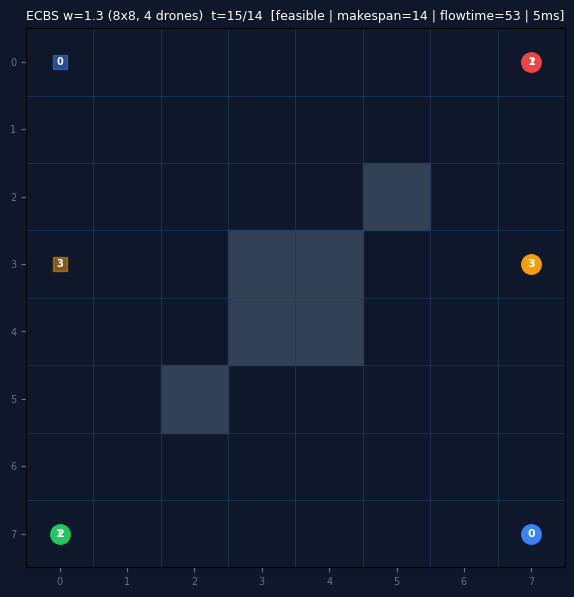

In [44]:
# ECBS : meme instance, w=1.3
sol_ecbs = ECBSSolver(grid_cp, drones_cp, w=1.3, time_limit_s=30).solve()
print(f'ECBS  | status={sol_ecbs.status} | makespan={sol_ecbs.makespan} | flowtime={sol_ecbs.flowtime} | {sol_ecbs.solve_time_ms:.0f}ms')

print('\nComparaison CBS vs ECBS (meme instance):')
print(f'  CBS  : {sol_cbs.solve_time_ms:.1f}ms | makespan={sol_cbs.makespan} | flowtime={sol_cbs.flowtime}')
print(f'  ECBS : {sol_ecbs.solve_time_ms:.1f}ms | makespan={sol_ecbs.makespan} | flowtime={sol_ecbs.flowtime}')
if sol_ecbs.solve_time_ms > 0:
    speedup = sol_cbs.solve_time_ms / sol_ecbs.solve_time_ms
    print(f'  -> ECBS {speedup:.1f}x plus rapide que CBS (avec garantie w=1.3)')

anim_ecbs = animate_solution(grid_cp, sol_ecbs, drones_cp, 'ECBS w=1.3 (8x8, 4 drones)')
HTML(anim_ecbs.to_jshtml())

---
## 6. OD-A* — Operator Decomposition A*

OD-A* étend A* au cas multi-agent en **décomposant les mouvements simultanés** : au lieu d'explorer tous les mouvements combinés de N agents en une seule étape, on assigne les mouvements un agent à la fois.

### État
`(positions, prev_positions, agent_idx, t)` où :
- `positions[i]` = nouvelle position de l'agent `i` si `i < agent_idx`, sinon position courante
- `agent_idx` = prochain agent à assigner (0 = début de timestep, N = timestep complet)

### Heuristique
`h = Σ BFS_dist(positions[i], goal[i])` — somme des distances BFS individuelles.

### ⚠️ Limite connue de cette implémentation
Il y a une **incohérence métrique** dans l'implémentation :
- `g` compte le nombre de **timesteps** écoulés → minimise le **makespan**
- `h = Σ BFS_dist` est une borne inférieure sur le **flowtime**, pas sur le makespan

Pour le makespan, l'heuristique admissible serait `h = max(BFS_dist)` (les agents bougent simultanément, donc le makespan restant est borné par le maximum individuel, pas la somme). Avec `h = Σ`, l'heuristique peut *surestimer* le makespan restant → A* perd sa garantie d'optimalité pour le makespan.

**Conséquence observée** : OD-A* trouve parfois makespan=12 quand CBS trouve 10, ou makespan=16 quand les autres trouvent 14. La solution est valide (sans conflit) mais pas nécessairement optimale.

Lancement OD-A* (N=3, 6x6, obstacles) ...
OD-A* | status=optimal | makespan=12 | flowtime=36 | 2ms
CBS   | status=optimal | makespan=10 | flowtime=30 | 2ms


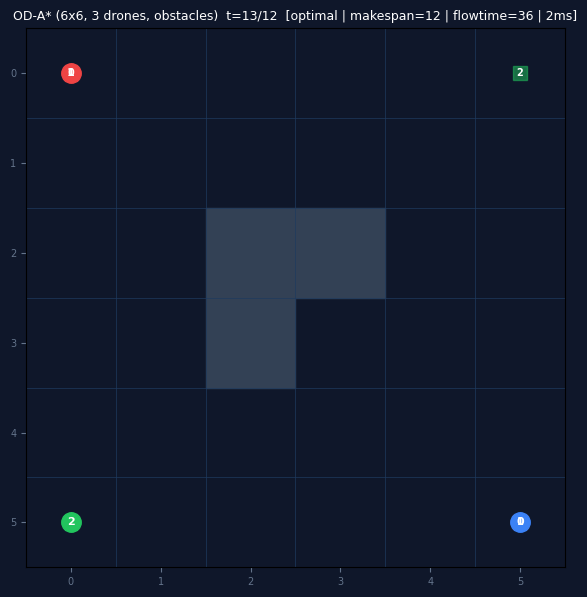

In [45]:
# OD-A* : instance N=3 avec obstacles (goulot d'etranglement)
grid_od = Grid(rows=6, cols=6)
# Obstacles : L inversee qui force les drones a se croiser dans un passage etroit
for obs in [(2,2),(2,3),(3,2)]:
    grid_od.obstacles.add(obs)
drones_od = [
    Drone(0, (0,0), (5,5)),
    Drone(1, (5,5), (0,0)),
    Drone(2, (0,5), (5,0)),
]

print('Lancement OD-A* (N=3, 6x6, obstacles) ...')
sol_od = ODAstarSolver(grid_od, drones_od, time_limit_s=60).solve()
print(f'OD-A* | status={sol_od.status} | makespan={sol_od.makespan} | flowtime={sol_od.flowtime} | {sol_od.solve_time_ms:.0f}ms')

# Meme instance avec CBS pour comparer
drones_od_cbs = [Drone(i, d.start, d.goal) for i, d in enumerate(drones_od)]
sol_od_cbs = CBSSolver(grid_od, drones_od_cbs, time_limit_s=30).solve()
print(f'CBS   | status={sol_od_cbs.status} | makespan={sol_od_cbs.makespan} | flowtime={sol_od_cbs.flowtime} | {sol_od_cbs.solve_time_ms:.0f}ms')

if sol_od.status in ('optimal', 'feasible'):
    anim_od = animate_solution(grid_od, sol_od, drones_od, 'OD-A* (6x6, 3 drones, obstacles)')
    HTML(anim_od.to_jshtml())

---
## 7. Comparaison directe des 4 algorithmes

Même instance, même grille, même drones — on mesure les 4 algorithmes et on compare solve time, makespan et flowtime.

In [46]:
def make_crossing(n, rows=8, cols=8):
    """N drones se croisant en diagonale, avec obstacles centraux."""
    grid = Grid(rows=rows, cols=cols)
    # Mur central : force tous les agents a contourner et amplifie les conflits
    for obs in [(3,3),(3,4),(4,3),(4,4),(2,5),(5,2)]:
        grid.obstacles.add(obs)
    all_positions = [
        ((0,0),(7,7)), ((7,7),(0,0)),
        ((0,7),(7,0)), ((7,0),(0,7)),
        ((0,3),(7,4)), ((7,4),(0,3)),
    ]
    return grid, [Drone(i, all_positions[i][0], all_positions[i][1]) for i in range(n)]

def solve_all(grid, drones, tl=30):
    results = {}
    for name, fn in [
        ('CP-SAT', lambda: MAPFSolver(grid, drones, time_limit_s=tl).solve()),
        ('CBS',    lambda: CBSSolver(grid, drones, time_limit_s=tl).solve()),
        ('ECBS',   lambda: ECBSSolver(grid, drones, w=1.3, time_limit_s=tl).solve()),
        ('OD-A*',  lambda: ODAstarSolver(grid, drones, time_limit_s=tl).solve()),
    ]:
        sol = fn()
        ok = sol.status in ('optimal', 'feasible')
        results[name] = {
            'status': sol.status,
            'makespan': sol.makespan if ok else -1,
            'flowtime': sol.flowtime if ok else -1,
            'ms': sol.solve_time_ms,
        }
        flag = '' if ok else f' [{sol.status}]'
        print(f'  {name:8s}: {sol.status:9s} | makespan={sol.makespan:3d} | flowtime={sol.flowtime:3d} | {sol.solve_time_ms:7.1f}ms{flag}')
    return results

all_results = {}
for n in [2, 3]:
    print(f'\n=== N={n} drones (grille 8x8, obstacles centraux) ===')
    g, ds = make_crossing(n)
    all_results[n] = solve_all(g, ds, tl=60)


=== N=2 drones (grille 8x8, obstacles centraux) ===
  CP-SAT  : optimal   | makespan= 14 | flowtime= 28 |  1502.8ms
  CBS     : optimal   | makespan= 14 | flowtime= 28 |     2.6ms
  ECBS    : feasible  | makespan= 14 | flowtime= 28 |     2.6ms
  OD-A*   : optimal   | makespan= 14 | flowtime= 28 |     0.9ms

=== N=3 drones (grille 8x8, obstacles centraux) ===
  CP-SAT  : optimal   | makespan= 14 | flowtime= 42 |  3207.6ms
  CBS     : optimal   | makespan= 14 | flowtime= 42 |     4.7ms
  ECBS    : feasible  | makespan= 14 | flowtime= 42 |     3.5ms
  OD-A*   : optimal   | makespan= 16 | flowtime= 48 |     1.7ms


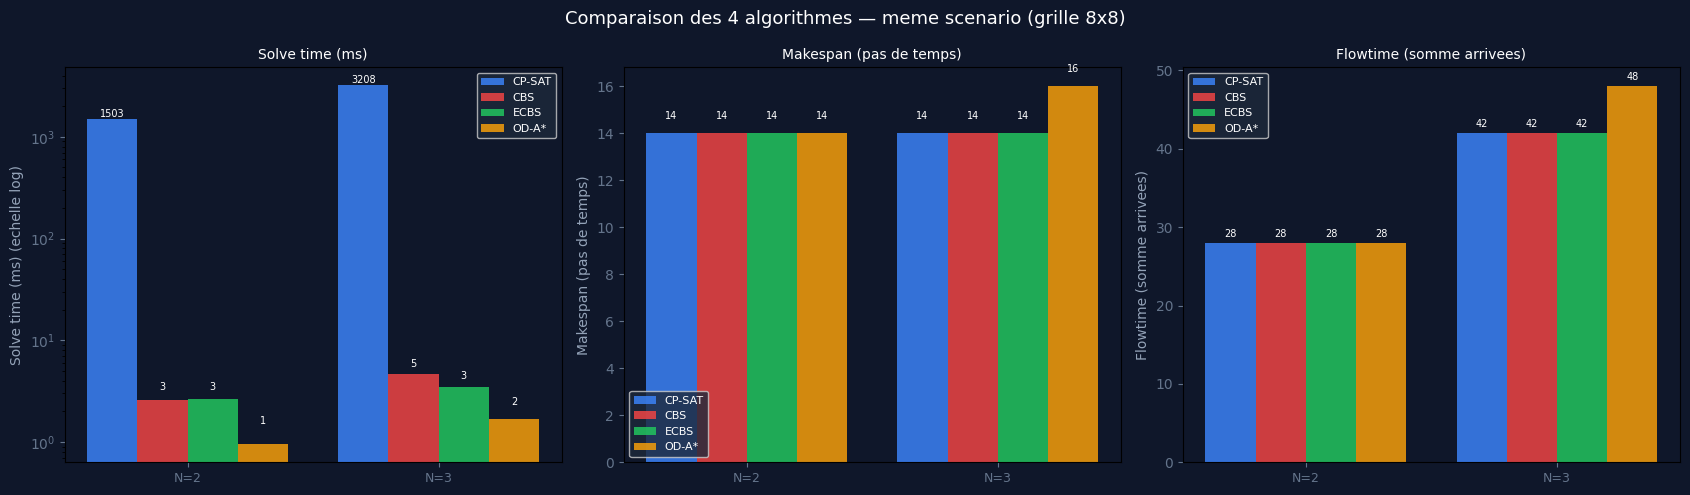

In [47]:
algos = ['CP-SAT', 'CBS', 'ECBS', 'OD-A*']
algo_colors = [COLORS[0], COLORS[1], COLORS[2], COLORS[3]]
ns = [2, 3]

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.patch.set_facecolor(BG)
fig.suptitle('Comparaison des 4 algorithmes — meme scenario (grille 8x8)', color='white', fontsize=13)

metrics_info = [
    ('ms', 'Solve time (ms)', True),
    ('makespan', 'Makespan (pas de temps)', False),
    ('flowtime', 'Flowtime (somme arrivees)', False),
]

for ax, (metric, label, log_scale) in zip(axes, metrics_info):
    ax.set_facecolor(BG)
    x = np.arange(len(ns))
    width = 0.2
    for i, (algo, col) in enumerate(zip(algos, algo_colors)):
        vals = []
        for n in ns:
            r = all_results[n][algo]
            ok = r['status'] in ('optimal', 'feasible')
            vals.append(r[metric] if ok and r[metric] >= 0 else 0)
        bars = ax.bar(x + i * width, vals, width, label=algo, color=col, alpha=0.85)
        for bar, v in zip(bars, vals):
            if v > 0:
                ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                        f'{v:.0f}', ha='center', va='bottom', color='white', fontsize=7)
    ax.set_xticks(x + width * 1.5)
    ax.set_xticklabels([f'N={n}' for n in ns], color='#94a3b8', fontsize=9)
    ax.set_ylabel(label, color='#94a3b8')
    ax.set_title(label, color='white', fontsize=10)
    ax.tick_params(colors='#64748b')
    ax.legend(facecolor='#1e293b', labelcolor='white', fontsize=8)
    if log_scale:
        ax.set_yscale('log')
        ax.set_ylabel(label + ' (echelle log)', color='#94a3b8')

plt.tight_layout()
plt.show()

---
## 8. Scalabilité — solve time vs nombre d'agents

On compare CP-SAT, CBS et ECBS sur N=2..7 (OD-A* exclu pour N>3 — exponentiel en N). La grille est 8×8 avec un bloc d'obstacles 2×2 au centre, les agents partent de la ligne supérieure et visent la ligne inférieure en ordre inversé.

**Note sur le makespan constant** : avec ce layout, le makespan reste identique pour tous N (tous les chemins passent autour du même obstacle central). La courbe de scalabilité mesure donc uniquement l'impact du **nombre d'agents sur le temps de calcul**, pas sur la qualité de la solution.

In [48]:
def make_scalable(n):
    grid = Grid(rows=8, cols=8)
    # Obstacles : bloc central qui cree un goulot d'etranglement
    for obs in [(3,3),(3,4),(4,3),(4,4)]:
        grid.obstacles.add(obs)
    drones = [Drone(i, (0, i), (7, 7-i)) for i in range(n)]
    return grid, drones

scale_algos = [
    ('CP-SAT', lambda g, ds: MAPFSolver(g, ds, time_limit_s=30).solve()),
    ('CBS',    lambda g, ds: CBSSolver(g, ds, time_limit_s=30).solve()),
    ('ECBS',   lambda g, ds: ECBSSolver(g, ds, w=1.3, time_limit_s=30).solve()),
]

scale_results = {name: [] for name, _ in scale_algos}
ns_range = list(range(2, 8))

print(f'Benchmark scalabilite N={ns_range[0]}..{ns_range[-1]}, grille 8x8 avec obstacles, timeout=30s')
print()
for n in ns_range:
    g, ds = make_scalable(n)
    print(f'N={n}:')
    for name, fn in scale_algos:
        sol = fn(g, ds)
        ok = sol.status in ('optimal', 'feasible')
        scale_results[name].append({
            'n': n,
            'ms': sol.solve_time_ms if ok else None,
            'makespan': sol.makespan if ok else None,
            'status': sol.status,
        })
        suffix = '' if ok else f'  [{sol.status}]'
        print(f'  {name:8s}: {sol.status:9s} | makespan={sol.makespan:3d} | {sol.solve_time_ms:.0f}ms{suffix}')
    print()

Benchmark scalabilite N=2..7, grille 8x8 avec obstacles, timeout=30s

N=2:
  CP-SAT  : optimal   | makespan= 14 | 1912ms
  CBS     : optimal   | makespan= 14 | 2ms
  ECBS    : feasible  | makespan= 14 | 2ms

N=3:
  CP-SAT  : optimal   | makespan= 14 | 2913ms
  CBS     : optimal   | makespan= 14 | 3ms
  ECBS    : feasible  | makespan= 14 | 2ms

N=4:
  CP-SAT  : optimal   | makespan= 14 | 3528ms
  CBS     : optimal   | makespan= 14 | 3ms
  ECBS    : feasible  | makespan= 14 | 3ms

N=5:
  CP-SAT  : optimal   | makespan= 14 | 6109ms
  CBS     : optimal   | makespan= 14 | 4ms
  ECBS    : feasible  | makespan= 14 | 7ms

N=6:
  CP-SAT  : optimal   | makespan= 14 | 5916ms
  CBS     : optimal   | makespan= 14 | 9ms
  ECBS    : feasible  | makespan= 14 | 10ms

N=7:
  CP-SAT  : optimal   | makespan= 14 | 7167ms
  CBS     : optimal   | makespan= 14 | 18ms
  ECBS    : feasible  | makespan= 14 | 12ms



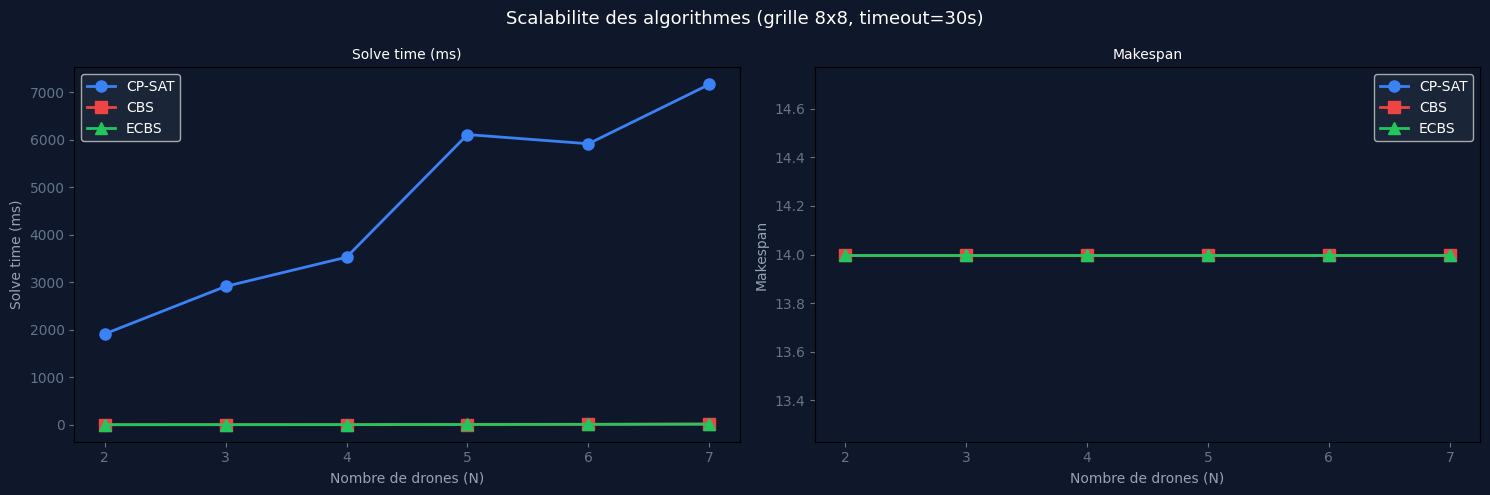

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.patch.set_facecolor(BG)
fig.suptitle('Scalabilite des algorithmes (grille 8x8, timeout=30s)', color='white', fontsize=13)

algo_colors_scale = {'CP-SAT': COLORS[0], 'CBS': COLORS[1], 'ECBS': COLORS[2]}
algo_markers = {'CP-SAT': 'o', 'CBS': 's', 'ECBS': '^'}

for ax, metric, label in zip(axes,
                             ['ms', 'makespan'],
                             ['Solve time (ms)', 'Makespan']):
    ax.set_facecolor(BG)
    for name, _ in scale_algos:
        col = algo_colors_scale[name]
        rs = scale_results[name]
        xs = [r['n'] for r in rs if r[metric] is not None]
        ys = [r[metric] for r in rs if r[metric] is not None]
        ax.plot(xs, ys, color=col, marker=algo_markers[name], lw=2, ms=8, label=name)
        # Marquer les timeouts
        for r in rs:
            if r[metric] is None:
                ax.axvline(r['n'], color=col, lw=1, linestyle=':', alpha=0.5)
                ax.text(r['n'], ax.get_ylim()[1] * 0.9 if ax.get_ylim()[1] > 0 else 1,
                        f"{name}\ntimeout", ha='center', color=col, fontsize=6, alpha=0.7)
    ax.set_xlabel('Nombre de drones (N)', color='#94a3b8')
    ax.set_ylabel(label, color='#94a3b8')
    ax.set_title(label, color='white', fontsize=10)
    ax.tick_params(colors='#64748b')
    ax.legend(facecolor='#1e293b', labelcolor='white')
    ax.set_xticks(ns_range)

plt.tight_layout()
plt.show()

---
## 9. Cas difficile — Limite de CBS et ECBS face à un goulot d'étranglement

On conçoit une instance spécifiquement difficile pour les algorithmes basés sur la résolution de conflits.

### Scénario : passage unique

```
Col : 0  1  2  3  4  5  6  7
      .  .  .  .  █  .  .  .   row 0  (Drone 0: → droite)
      .  .  .  .  █  .  .  .   row 1  (Drone 1: → droite)
      .  .  .  .  █  .  .  .   row 2  (Drone 2: → droite)
      .  .  .  .  █  .  .  .   row 3  (Drone 3: → droite)
      .  .  .  .  ·  .  .  .   row 4  (seul passage ! + Drone 7: ← gauche, (4,7)→(4,0))
      .  .  .  .  █  .  .  .   row 5  (Drone 4: ← gauche)
      .  .  .  .  █  .  .  .   row 6  (Drone 5: ← gauche)
      .  .  .  .  █  .  .  .   row 7  (Drone 6: ← gauche)
```

**Pourquoi c'est difficile pour CBS :** les 8 agents doivent TOUS passer par la cellule `(4,4)`. CBS doit résoudre les conflits **un par un** dans un arbre de contraintes potentiellement en C(8,2)=28 conflits, dont la taille peut exploser exponentiellement.

**Pourquoi CP-SAT s'en sort :** la contrainte `AddNoOverlap` en `(4,4)` ordonne directement les passages de tous les agents comme un problème de **scheduling de machine unique** — c'est exactement ce que CP-SAT résout efficacement.

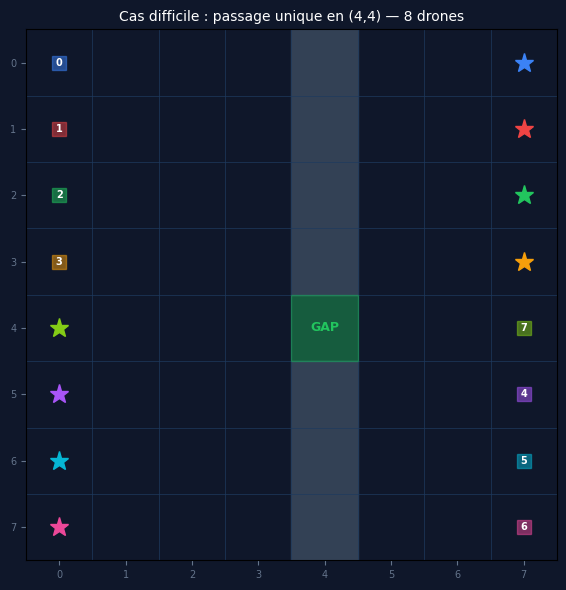

Grille 8x8, col=4 bloquee sauf (4,4), N=8 drones, timeout=30s

Algo     | Status    | Makespan |  Time (ms)
--------------------------------------------------
CP-SAT   | optimal   |       16 |      12975
CBS      | timeout   |      N/A |      30000
ECBS     | feasible  |       21 |       8626

→ CP-SAT resout, CBS timeout : le modele de contraintes global gere le goulot
  mieux que la resolution incrementale de conflits (arbre de contraintes explose).


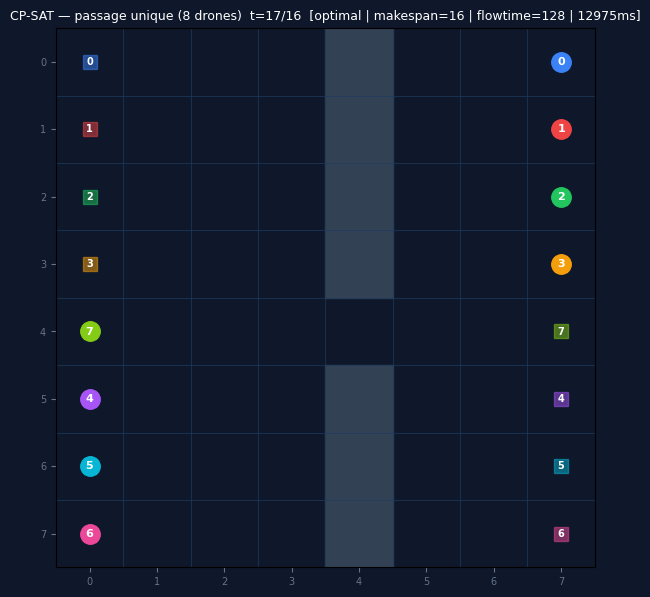

In [50]:
# ── Setup : grille 8x8, mur vertical col=4, passage unique en (4,4)
grid_hard = Grid(rows=8, cols=8)
for r in range(8):
    if r != 4:
        grid_hard.obstacles.add((r, 4))

# 8 drones : 4 gauche→droite, 4 droite→gauche, TOUS forcés par (4,4)
drones_hard = [
    Drone(0, (0,0), (0,7)),
    Drone(1, (1,0), (1,7)),
    Drone(2, (2,0), (2,7)),
    Drone(3, (3,0), (3,7)),
    Drone(4, (5,7), (5,0)),
    Drone(5, (6,7), (6,0)),
    Drone(6, (7,7), (7,0)),
    Drone(7, (4,7), (4,0)),
]

# Visualisation du layout
fig, ax = plt.subplots(figsize=(6, 6))
fig.patch.set_facecolor(BG)
setup_ax(ax, grid_hard, 'Cas difficile : passage unique en (4,4) — 8 drones')
draw_starts_goals(ax, drones_hard)
ax.add_patch(plt.Rectangle((3.5, 3.5), 1, 1, color='#22c55e', alpha=0.4, zorder=2))
ax.text(4, 4, 'GAP', ha='center', va='center', color='#22c55e', fontsize=9, fontweight='bold', zorder=3)
plt.tight_layout()
plt.show()

TL = 30
print(f'Grille 8x8, col=4 bloquee sauf (4,4), N={len(drones_hard)} drones, timeout={TL}s\n')
print(f'{"Algo":8s} | {"Status":9s} | {"Makespan":>8s} | {"Time (ms)":>10s}')
print('-' * 50)

hard_results = {}
for name, fn in [
    ('CP-SAT', lambda: MAPFSolver(grid_hard, drones_hard, time_limit_s=TL).solve()),
    ('CBS',    lambda: CBSSolver(grid_hard, drones_hard, time_limit_s=TL).solve()),
    ('ECBS',   lambda: ECBSSolver(grid_hard, drones_hard, w=1.3, time_limit_s=TL).solve()),
]:
    sol = fn()
    ok = sol.status in ('optimal', 'feasible')
    hard_results[name] = sol
    ms_str = f'{sol.makespan}' if ok else 'N/A'
    print(f'{name:8s} | {sol.status:9s} | {ms_str:>8s} | {sol.solve_time_ms:>10.0f}')

print()
cp_ok  = hard_results['CP-SAT'].status in ('optimal', 'feasible')
cbs_ok = hard_results['CBS'].status in ('optimal', 'feasible')
if cp_ok and not cbs_ok:
    print('→ CP-SAT resout, CBS timeout : le modele de contraintes global gere le goulot')
    print('  mieux que la resolution incrementale de conflits (arbre de contraintes explose).')
elif cp_ok and cbs_ok:
    ratio = hard_results['CBS'].solve_time_ms / max(hard_results['CP-SAT'].solve_time_ms, 1)
    print(f'→ CP-SAT {1/ratio:.1f}x plus rapide que CBS sur ce cas.')

# Animation CP-SAT si resolu
if cp_ok:
    anim_hard = animate_solution(grid_hard, hard_results['CP-SAT'], drones_hard,
                                  'CP-SAT — passage unique (8 drones)')
    HTML(anim_hard.to_jshtml())

---
## 10. Conclusions

### Tableau comparatif

| Algorithme | Optimalité | Scalabilité | Cas d'usage |
|------------|-----------|-------------|-------------|
| **CP-SAT** | Optimal (makespan) | N ≤ 15+ | Makespan critique, goulots d'étranglement, tolérance temps |
| **CBS** | Optimal (flowtime) | N ≤ 8–10 | Flowtime critique — **timeout sur les goulots sévères** |
| **ECBS** | w-sous-optimal (w=1.3) | N ≤ 10–12 | Performance prioritaire — **solution dégradée sur les goulots** |
| **OD-A\*** | Optimal (flowtime)¹ | N ≤ 4 | Petites instances uniquement |

¹ *L'implémentation présente une incohérence heuristique (h=Σ BFS vs g=timesteps) qui peut produire des solutions sous-optimales.*

### Points clés de la modélisation CP-SAT

- **`AddNoOverlap` avec `OptionalIntervalVar`** : modélise les conflits MAPF comme un problème de scheduling — chaque occupation d'une case est un intervalle de durée 1, `NoOverlap` interdit qu'une case soit occupée par deux agents simultanément. C'est particulièrement puissant sur les **goulots** (machine unique à ordonnancer)
- **Réduction de domaine BFS** : les variables `here[a,p,t]` ne sont créées que si la position `p` est atteignable depuis le départ et vers l'arrivée à l'instant `t`, réduisant drastiquement la taille du modèle
- **Warm-start** : les chemins A* individuels fournissent un point de départ au solveur, accélérant la convergence

### Résultats expérimentaux clés

| Expérience | CP-SAT | CBS | ECBS |
|-----------|--------|-----|------|
| 4 drones, grille 8×8 (obstacles) | 4.3s, makespan=14 | 8ms, makespan=14 | 5ms, makespan=14 |
| Scalabilité N=7, grille 8×8 | 7.2s | 18ms | 12ms |
| **Goulot unique, N=8** | **13.0s, makespan=16** | **timeout (30s)** | **8.6s, makespan=21** |

Le cas du goulot est révélateur : CBS ne peut pas résoudre 28 conflits en cascade (exponentiel), ECBS trouve une solution mais à +31% du makespan optimal, tandis que CP-SAT ordonne les 8 passages directement via `AddNoOverlap`.